# Netflix stock analysis

#objectives
1.Volume of stock traded
2.Netflix stock price-High,Open,Close
3.Netflix stock price-Day,Month,Yearwise
4.Top-5 dates with highest stock price
5.To[-5 dates with lowest stock price

In [30]:
#1st step:-data clean/preprocessing using pandas,numpy
#2nd step:-for visualization using matplotlib,seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [31]:
df=pd.read_csv("netflix.csv")

In [32]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Quarter
0,02-01-2019,259.279999,269.750000,256.579987,267.660004,267.660004,11679500,Q1 2019
1,03-01-2019,270.200012,275.790009,264.429993,271.200012,271.200012,14969600,Q1 2019
2,04-01-2019,281.880005,297.799988,278.540009,297.570007,297.570007,19330100,Q1 2019
3,07-01-2019,302.100006,316.799988,301.649994,315.339996,315.339996,18620100,Q1 2019
4,08-01-2019,319.980011,320.589996,308.010010,320.269989,320.269989,15359200,Q1 2019


In [33]:
sns.set(rc={'figure.figsize':(10,5)})

In [34]:
import pandas as pd

# Option 1: dayfirst=True (Best for DD-MM-YYYY)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Option 2: Explicit format (Agar format fix hai)
# df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Index set karna aur check karna
df = df.set_index('Date')
df.head()

,Open,High,Low,Close,Adj Close,Volume,Quarter
Date,,,,,,,
2019-01-02,259.279999,269.750000,256.579987,267.660004,267.660004,11679500,Q1 2019
2019-01-03,270.200012,275.790009,264.429993,271.200012,271.200012,14969600,Q1 2019
2019-01-04,281.880005,297.799988,278.540009,297.570007,297.570007,19330100,Q1 2019
2019-01-07,302.100006,316.799988,301.649994,315.339996,315.339996,18620100,Q1 2019
2019-01-08,319.980011,320.589996,308.010010,320.269989,320.269989,15359200,Q1 2019


Text(0.5, 1.0, 'volume f stock versus time')

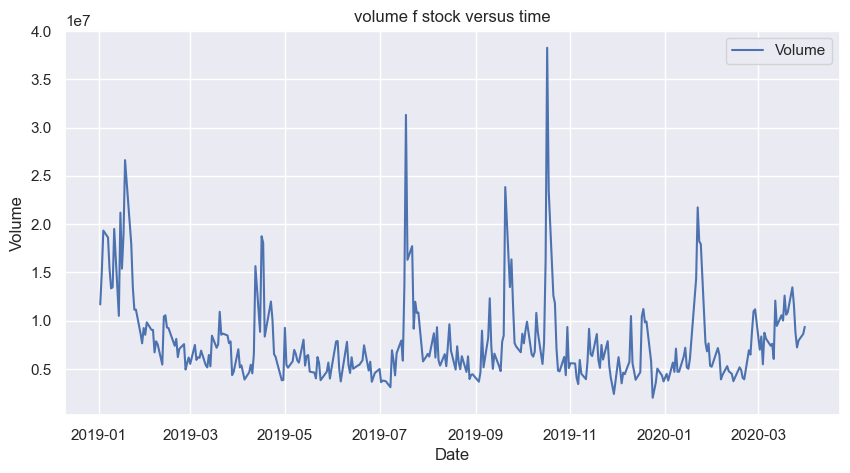

In [35]:
#1.Volume of stock traded
sns.lineplot(x=df.index ,y=df['Volume'], label='Volume' )
plt.title('volume f stock versus time')

<Axes: title={'center': 'Netflix stock Prices'}, xlabel='Date'>

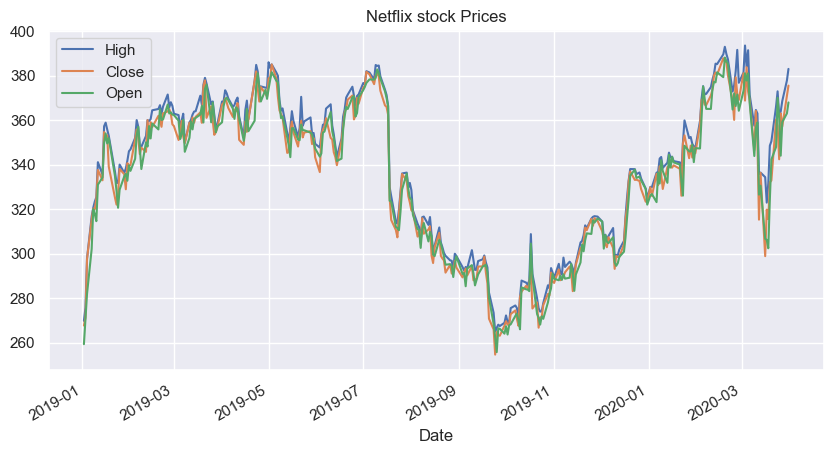

In [36]:
#2.Netflix stock price-High,Open,Close
df.plot(y=['High', 'Close', 'Open'],title='Netflix stock Prices')

In [37]:
print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Quarter'], dtype='object')


In [44]:
print(df.index.year.unique())

Index([2019, 2020], dtype='int32', name='Date')


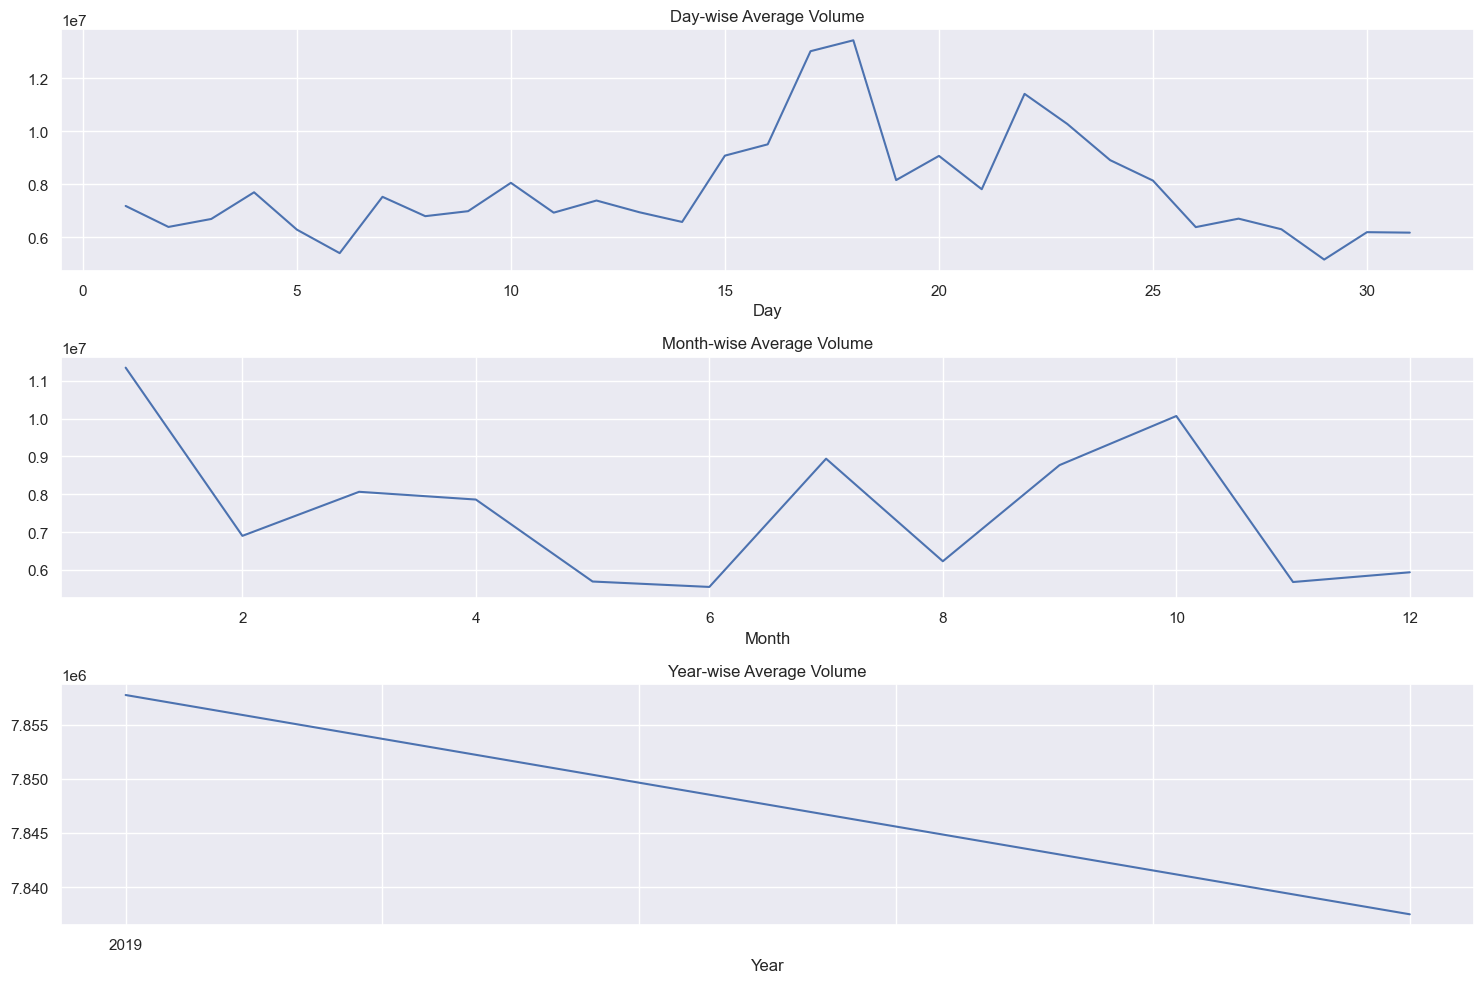

In [43]:
import matplotlib.pyplot as plt

# Figsize aur 3 subplots setup
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(15,10))

# 1. Day-wise Plot
df.groupby(df.index.day)['Volume'].mean().plot(ax=ax1, xlabel='Day', title='Day-wise Average Volume')

# 2. Month-wise Plot 
df.groupby(df.index.month)['Volume'].mean().plot(ax=ax2, xlabel='Month', title='Month-wise Average Volume')

# 3. Year-wise Plot (Fix: astype(str) se year sahi dikhega)
df.groupby(df.index.year.astype(str))['Volume'].mean().plot(ax=ax3, xlabel='Year', title='Year-wise Average Volume')

plt.tight_layout()
plt.show()

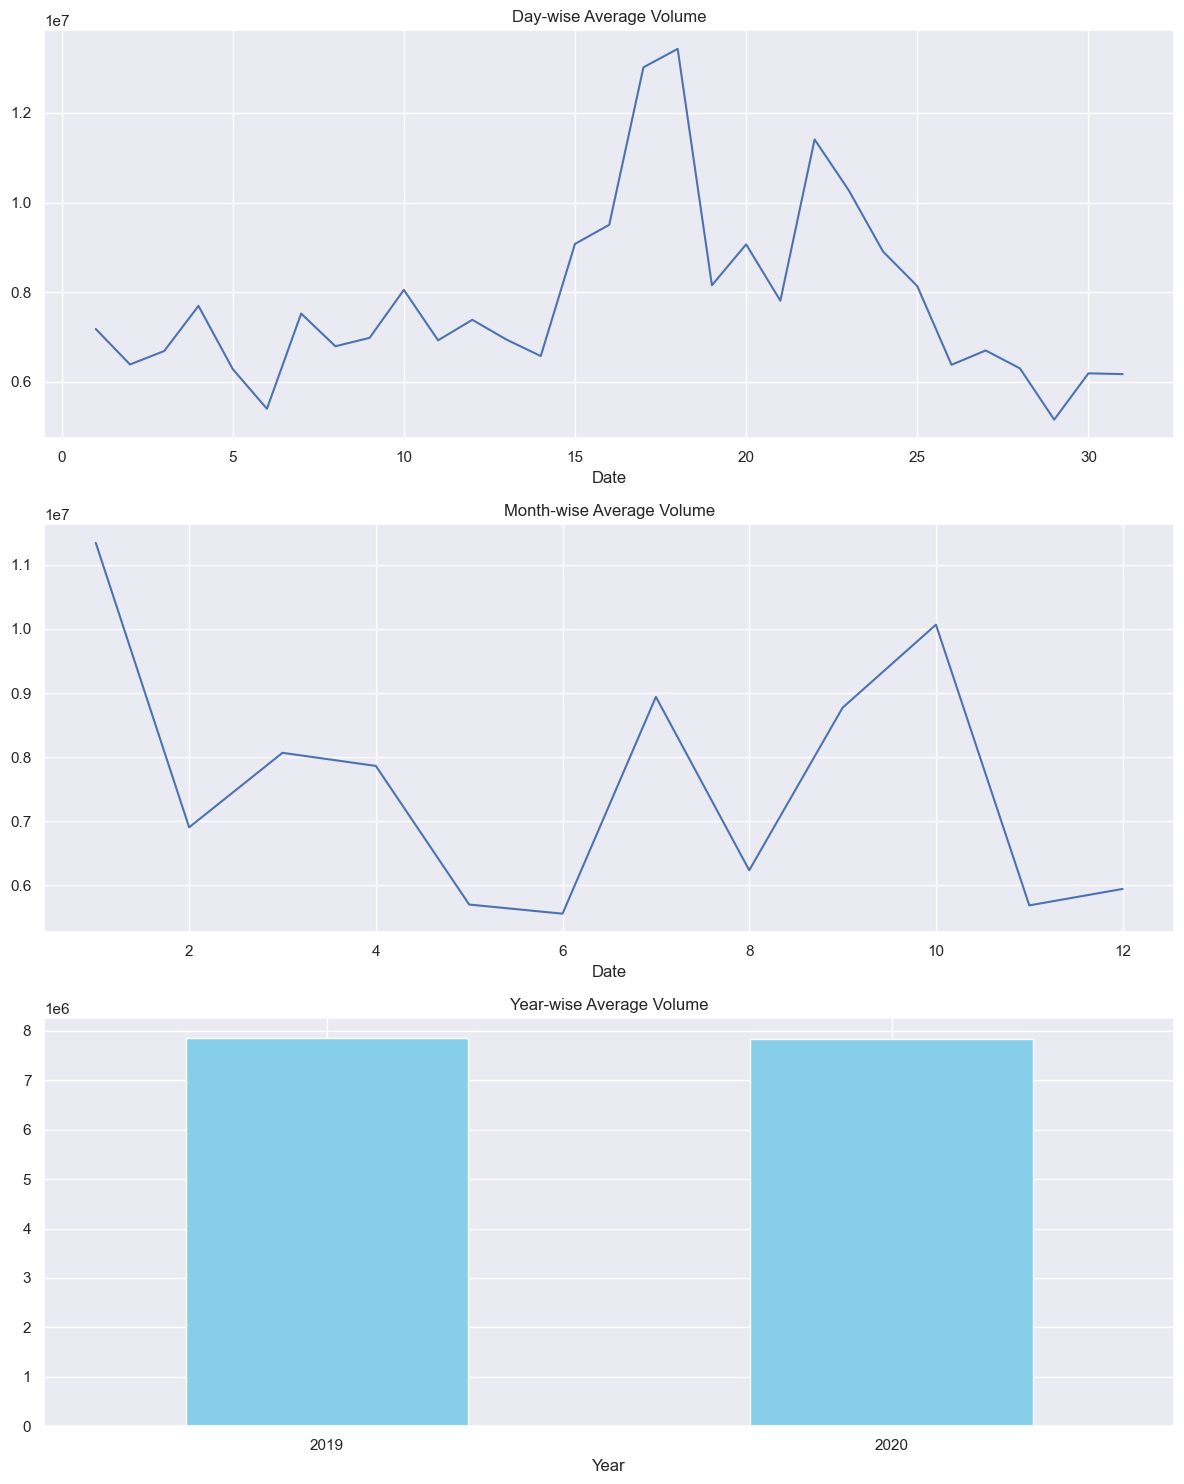

In [45]:
import matplotlib.pyplot as plt

# Figsize aur 3 subplots setup
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(12,15))

# 1. Day-wise (Line graph sahi hai)
df.groupby(df.index.day)['Volume'].mean().plot(ax=ax1, title='Day-wise Average Volume')

# 2. Month-wise (Line graph sahi hai)
df.groupby(df.index.month)['Volume'].mean().plot(ax=ax2, title='Month-wise Average Volume')

# 3. Year-wise (FIX: Bar graph use karein taaki 2019 aur 2020 saaf dikhe)
df.groupby(df.index.year.astype(str))['Volume'].mean().plot(kind='bar', ax=ax3, color='skyblue')

# Labels ko thoda set kar dete hain
ax3.set_title('Year-wise Average Volume')
ax3.set_xlabel('Year')
ax3.set_xticklabels(['2019', '2020'], rotation=0) # Year ko seedha aur saaf dikhane ke liye

plt.tight_layout()
plt.show()

In [46]:
#4.Top-5 dates with highest stock price 


In [47]:
df

,Open,High,Low,Close,Adj Close,Volume,Quarter
Date,,,,,,,
2019-01-02,259.279999,269.750000,256.579987,267.660004,267.660004,11679500,Q1 2019
2019-01-03,270.200012,275.790009,264.429993,271.200012,271.200012,14969600,Q1 2019
2019-01-04,281.880005,297.799988,278.540009,297.570007,297.570007,19330100,Q1 2019
2019-01-07,302.100006,316.799988,301.649994,315.339996,315.339996,18620100,Q1 2019
2019-01-08,319.980011,320.589996,308.010010,320.269989,320.269989,15359200,Q1 2019
...,...,...,...,...,...,...,...
2020-03-25,361.019989,362.000000,339.170013,342.390015,342.390015,8767200,Q1 2020
2020-03-26,344.000000,363.839996,341.730011,362.989990,362.989990,7229600,Q1 2020
2020-03-27,359.089996,368.559998,353.000000,357.119995,357.119995,7948800,Q1 2020


In [48]:
a=df.sort_values(by='High', ascending=False).head(5)
a['High']

Date
2020-03-03    393.519989
2020-02-19    392.950012
2020-02-27    391.559998
2020-03-05    391.399994
2020-02-20    389.700012
Name: High, dtype: float64

In [49]:
#top 5 dates of tock prices loe
a=df.sort_values(by='Low', ascending=True).head(5)
a['Low']

Date
2019-09-24    252.279999
2019-09-25    253.699997
2019-01-02    256.579987
2019-10-03    257.010010
2019-09-26    260.200012
Name: Low, dtype: float64

<Axes: xlabel='Date', ylabel='Low'>

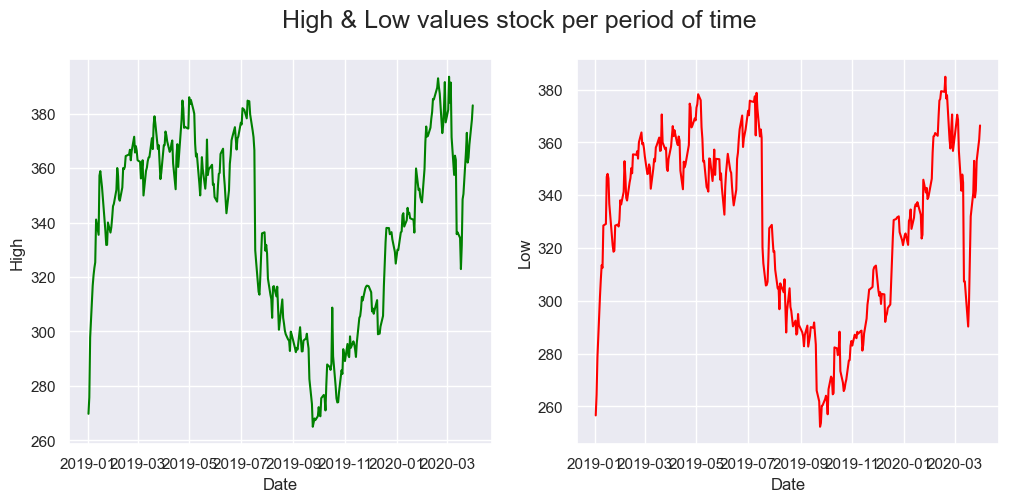

In [52]:
#plot Graph of High and Low
# do graph hoga ek hi row m
fig,axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(12,5))
fig.suptitle('High & Low values stock per period of time', fontsize=18)
sns.lineplot(ax=axes[0], y=df['High'], x=df.index, color='green')
sns.lineplot(ax=axes[1], y=df['Low'], x=df.index, color='red')